In [1]:
import json

import agama
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import gaussian_kde, norm

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()


# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [2]:
def cartesian_to_cylindrical(pxyz, vxyz):
    x = pxyz[:, 0]
    y = pxyz[:, 1]
    z = pxyz[:, 2]

    vx = vxyz[:, 0]
    vy = vxyz[:, 1]
    vz = vxyz[:, 2]

    R = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)

    # avoid divide-by-zero
    R_safe = np.where(R == 0, 1e-10, R)

    v_R = (x * vx + y * vy) / R_safe
    v_phi = (x * vy - y * vx) / R_safe
    v_z = vz

    pcyl = np.column_stack((R, phi, z))
    vcyl = np.column_stack((v_R, v_phi, v_z))

    return pcyl, vcyl

In [3]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"
# fire_dir = sim_dir + sim + "/" + sim + "_res7100"
snap = 600

pot_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
pot_nbody = agama.Potential(pot_file)
af = agama.ActionFinder(pot_nbody, interp=False)

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
scmap = plt.get_cmap("tab10")
colors = [scmap(i) for i in np.linspace(0, 1, len(sim_lst))]
sim_colors = {sim: colors[i] for i, sim in enumerate(sim_lst)}

In [4]:
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

In [5]:
bins = np.arange(-1, 1.05, 0.05)

hist_dict = {"ins_sum": None, "ind_sum": None, "exs_sum": None, "exd_sum": None, "n": 0}

for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    in_flag = src_dat["grpid"][()] == 0
    s_flag = src_dat["s_flag"][()].astype(bool)

    pxyz = src_dat["pxyz_snap600"][()]
    vxyz = src_dat["vxyz_snap600"][()]

    posvel = np.column_stack((pxyz, vxyz))
    lz = af(posvel)[:, 2]

    ek = 0.5 * np.sum(np.array(vxyz) ** 2, axis=1)
    ep = pot_nbody.potential(pxyz)
    et = ek + ep

    r_circs = pot_nbody.Rcirc(E=et)
    xyz = np.column_stack((r_circs, r_circs * 0, r_circs * 0))
    v_circs = np.sqrt(-r_circs * pot_nbody.force(xyz)[:, 0])
    vel = np.column_stack((v_circs * 0, v_circs, v_circs * 0))
    init_conds = np.concatenate((xyz, vel), axis=1)
    lz_circ = af(init_conds)[:, 2]

    circularity = lz / np.array(lz_circ)

    ins_circ = circularity[in_flag & s_flag]
    ind_circ = circularity[in_flag & ~s_flag]
    exs_circ = circularity[~in_flag & s_flag]
    exd_circ = circularity[~in_flag & ~s_flag]

    hins, _ = np.histogram(ins_circ, bins=bins)
    hind, _ = np.histogram(ind_circ, bins=bins)
    hexs, _ = np.histogram(exs_circ, bins=bins)
    hexd, _ = np.histogram(exd_circ, bins=bins)

    if hist_dict["ins_sum"] is None:
        hist_dict["ins_sum"] = hins.astype(float)
        hist_dict["ind_sum"] = hind.astype(float)
        hist_dict["exs_sum"] = hexs.astype(float)
        hist_dict["exd_sum"] = hexd.astype(float)
    else:
        hist_dict["ins_sum"] += hins
        hist_dict["ind_sum"] += hind
        hist_dict["exs_sum"] += hexs
        hist_dict["exd_sum"] += hexd

    hist_dict["n"] += 1

ins_sum = hist_dict["ins_sum"] / hist_dict["n"]
ind_sum = hist_dict["ind_sum"] / hist_dict["n"]
exs_sum = hist_dict["exs_sum"] / hist_dict["n"]
exd_sum = hist_dict["exd_sum"] / hist_dict["n"]

Text(0, 0.5, 'density')

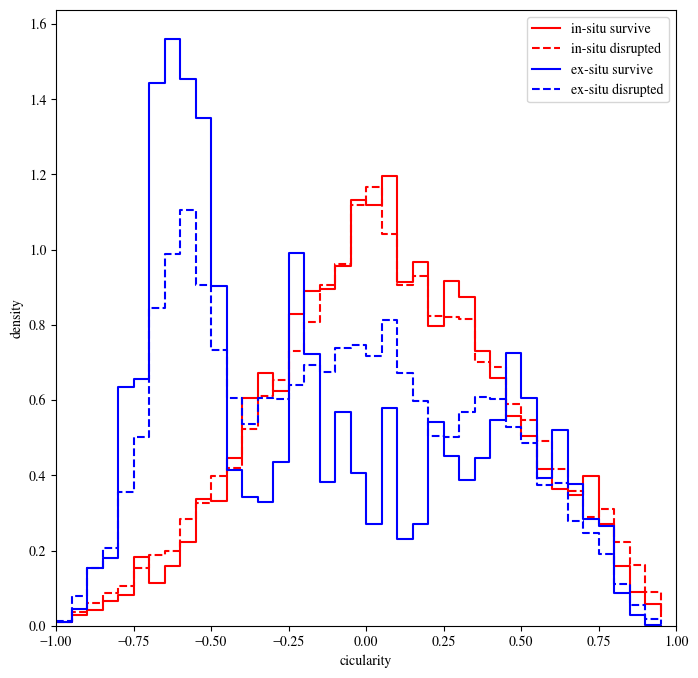

In [6]:
widths = bins[1:] - bins[:-1]

ins_sum = ins_sum / np.sum(ins_sum * widths)
ind_sum = ind_sum / np.sum(ind_sum * widths)
exs_sum = exs_sum / np.sum(exs_sum * widths)
exd_sum = exd_sum / np.sum(exd_sum * widths)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

ax.step(bins[:-1], ins_sum, where="post", color="r", label="in-situ survive")
ax.step(bins[:-1], ind_sum, where="post", color="r", ls="--", label="in-situ disrupted")
ax.step(bins[:-1], exs_sum, where="post", color="b", label="ex-situ survive")
ax.step(bins[:-1], exd_sum, where="post", color="b", ls="--", label="ex-situ disrupted")

# ax.step(bins[:-1], ins_sum, where="post", color="r", label="in-situ survive")
# ax.step(bins[:-1], ins_sum, where="post", color="r", label="in-situ survive")

ax.set_xlim(-1, 1)
ax.set_ylim(0)
ax.legend()

ax.set_xlabel("cicularity")
ax.set_ylabel("density")

In [7]:
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

bins = np.arange(-4.5, 0.75, 0.25)

hist_dict = {"ins_sum": None, "ind_sum": None, "exs_sum": None, "exd_sum": None, "n": 0}

for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    in_flag = src_dat["grpid"][()] == 0
    s_flag = src_dat["s_flag"][()].astype(bool)

    fehs = src_dat["feh"][()]

    ins_fehs = fehs[in_flag & s_flag]
    ind_fehs = fehs[in_flag & ~s_flag]
    exs_fehs = fehs[~in_flag & s_flag]
    exd_fehs = fehs[~in_flag & ~s_flag]

    hins, _ = np.histogram(ins_fehs, bins=bins)
    hind, _ = np.histogram(ind_fehs, bins=bins)
    hexs, _ = np.histogram(exs_fehs, bins=bins)
    hexd, _ = np.histogram(exd_fehs, bins=bins)

    if hist_dict["ins_sum"] is None:
        hist_dict["ins_sum"] = hins.astype(float)
        hist_dict["ind_sum"] = hind.astype(float)
        hist_dict["exs_sum"] = hexs.astype(float)
        hist_dict["exd_sum"] = hexd.astype(float)
    else:
        hist_dict["ins_sum"] += hins
        hist_dict["ind_sum"] += hind
        hist_dict["exs_sum"] += hexs
        hist_dict["exd_sum"] += hexd

    hist_dict["n"] += 1

ins_sum = hist_dict["ins_sum"] / hist_dict["n"]
ind_sum = hist_dict["ind_sum"] / hist_dict["n"]
exs_sum = hist_dict["exs_sum"] / hist_dict["n"]
exd_sum = hist_dict["exd_sum"] / hist_dict["n"]

Text(0, 0.5, 'density')

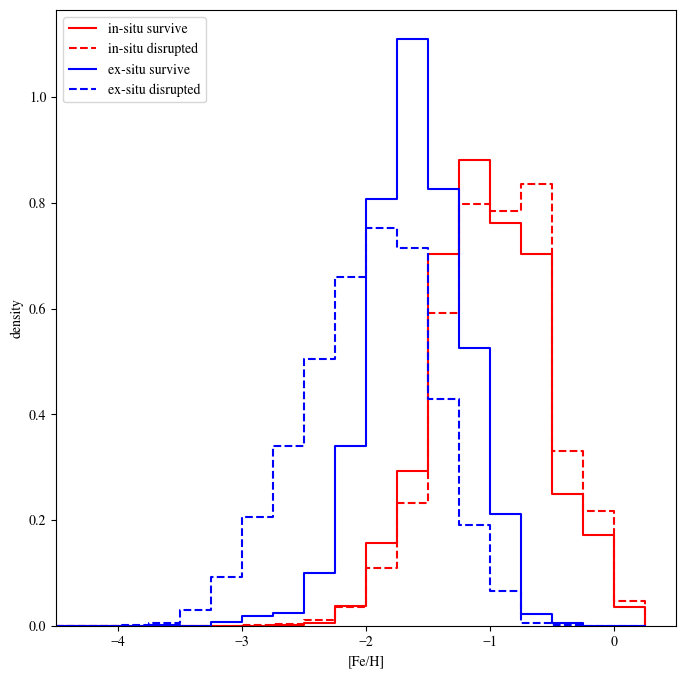

In [8]:
widths = bins[1:] - bins[:-1]

ins_sum = ins_sum / np.sum(ins_sum * widths)
ind_sum = ind_sum / np.sum(ind_sum * widths)
exs_sum = exs_sum / np.sum(exs_sum * widths)
exd_sum = exd_sum / np.sum(exd_sum * widths)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))

ax.step(bins[:-1], ins_sum, where="post", color="r", label="in-situ survive")
ax.step(bins[:-1], ind_sum, where="post", color="r", ls="--", label="in-situ disrupted")
ax.step(bins[:-1], exs_sum, where="post", color="b", label="ex-situ survive")
ax.step(bins[:-1], exd_sum, where="post", color="b", ls="--", label="ex-situ disrupted")

# ax.step(bins[:-1], ins_sum, where="post", color="r", label="in-situ survive")
# ax.step(bins[:-1], ins_sum, where="post", color="r", label="in-situ survive")

ax.set_xlim(-4.5, 0.5)
ax.set_ylim(0)
ax.legend(loc="upper left")

ax.set_xlabel("[Fe/H]")
ax.set_ylabel("density")

In [9]:
# sims = ["m12b", "m12c", "m12f", "m12i", "m12m"]


# fehs = np.array([])
# for sim in sims:
#     ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
#     ghost_data = h5py.File(ghost_file, "r")

#     for it_id in ghost_data.keys():
#         src_dat = ghost_data[it_id]["source"]

#         fehs = np.concatenate((fehs, src_dat["feh"][()]))

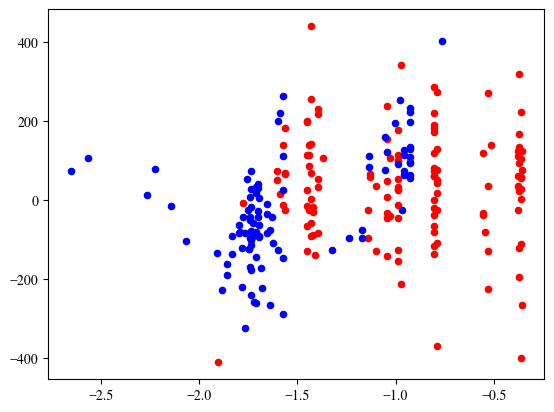

In [10]:
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

snp_dat = ghost_data["it001"]["snapshots"]["snap600"]
src_dat = ghost_data["it001"]["source"]

gcids_snp = snp_dat["gcid"][()]
vphi = snp_dat["host.vel.sph"][:, 2]  # spherical : r , angle theta, angle phi
insitu = snp_dat["grpid"][()] == 0

gcids_src = src_dat["gcid"][()]
feh_src = src_dat["feh"][()]

feh = []
for gcid in gcids_snp:
    gcidx = np.where(gcids_src == gcid)[0][0]
    feh.append(feh_src[gcidx])
feh = np.array(feh)

plt.scatter(feh[insitu], vphi[insitu], s=20, c="r")
plt.scatter(feh[~insitu], vphi[~insitu], s=20, c="b")

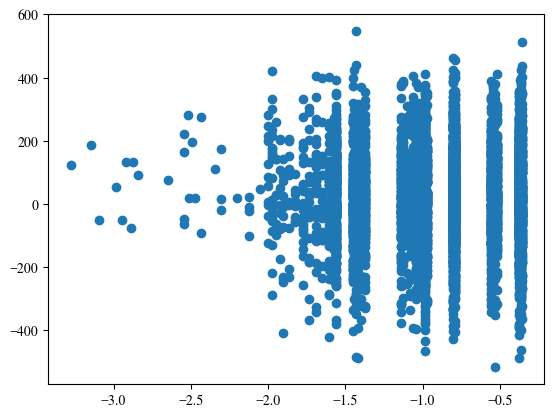

In [11]:
vxyz = src_dat["vxyz_snap600"][()]
pxyz = src_dat["pxyz_snap600"][()]

pcyl, vcyl = cartesian_to_cylindrical(pxyz, vxyz)

vphi = vcyl[:, 1]

feh = src_dat["feh"][()]
msk = src_dat["grpid"][()] == 0

plt.scatter(feh[msk], vphi[msk])

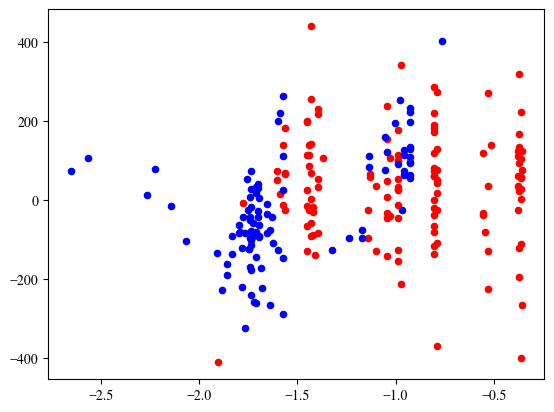

In [12]:
sim = "m12i"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

snp_dat = ghost_data["it001"]["snapshots"]["snap600"]
src_dat = ghost_data["it001"]["source"]

gcids_snp = snp_dat["gcid"][()]
vphi = snp_dat["host.vel.sph"][:, 2]  # spherical : r , angle theta, angle phi
insitu = snp_dat["grpid"][()] == 0

gcids_src = src_dat["gcid"][()]
feh_src = src_dat["feh"][()]

feh = []
for gcid in gcids_snp:
    gcidx = np.where(gcids_src == gcid)[0][0]
    feh.append(feh_src[gcidx])
feh = np.array(feh)

plt.scatter(feh[insitu], vphi[insitu], s=20, c="r")
plt.scatter(feh[~insitu], vphi[~insitu], s=20, c="b")

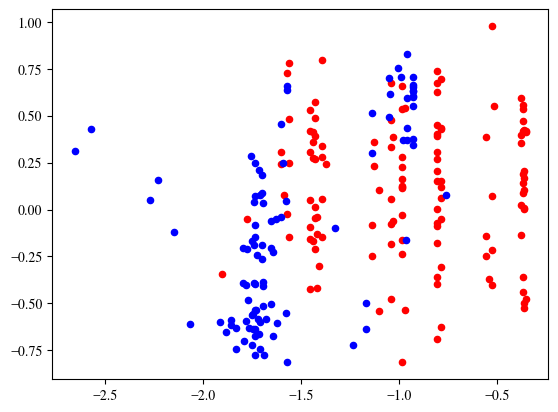

In [13]:
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

snp_dat = ghost_data["it001"]["snapshots"]["snap600"]
src_dat = ghost_data["it001"]["source"]

gcids_snp = snp_dat["gcid"][()]
vphi = snp_dat["circ"]
insitu = snp_dat["grpid"][()] == 0

gcids_src = src_dat["gcid"][()]
feh_src = src_dat["feh"][()]

feh = []
for gcid in gcids_snp:
    gcidx = np.where(gcids_src == gcid)[0][0]
    feh.append(feh_src[gcidx])
feh = np.array(feh)

plt.scatter(feh[insitu], vphi[insitu], s=20, c="r")
plt.scatter(feh[~insitu], vphi[~insitu], s=20, c="b")

In [14]:
snp_dat.keys()

<KeysViewHDF5 ['age', 'bnd_flag', 'circ', 'ecc', 'ek', 'ep', 'et', 'gcid', 'grpid', 'halo.pos.sph', 'halo.vel.sph', 'halo_tid', 'halo_tidx', 'host.pos.sph', 'host.vel.sph', 'inc', 'logm', 'nacc_flag', 'pidx', 'ptype', 's_flag', 'sa_flag', 'tideig']>

/Users/z5114326/Documents/GitHub/ghost_accretions/.venv312/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/z5114326/Documents/GitHub/ghost_accretions/.venv312/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


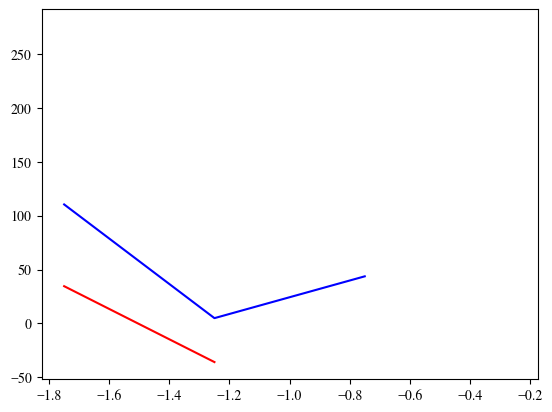

In [15]:
sim = "m12b"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

snp_dat = ghost_data["it001"]["snapshots"]["snap600"]
src_dat = ghost_data["it001"]["source"]

gcids_snp = snp_dat["gcid"][()]
vphi = snp_dat["host.vel.sph"][:, 2]  # spherical : r , angle theta, angle phi
insitu = snp_dat["grpid"][()] == 0

gcids_src = src_dat["gcid"][()]
feh_src = src_dat["feh"][()]

feh = []
for gcid in gcids_snp:
    gcidx = np.where(gcids_src == gcid)[0][0]
    feh.append(feh_src[gcidx])
feh = np.array(feh)

bins = np.arange(-2, 0.5, 0.5)
bin_idx = np.digitize(feh, bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
vphi_i = np.full(len(bin_centers), np.nan)
vphi_e = np.full(len(bin_centers), np.nan)

for i in range(1, len(bins)):
    mask = bin_idx == i
    if np.any(mask):
        in_i = insitu[mask]
        vphi_i[i - 1] = np.mean(vphi[mask][in_i])
        vphi_e[i - 1] = np.mean(vphi[mask][~in_i])

plt.plot(bin_centers, vphi_i, c="r")
plt.plot(bin_centers, vphi_e, c="b")

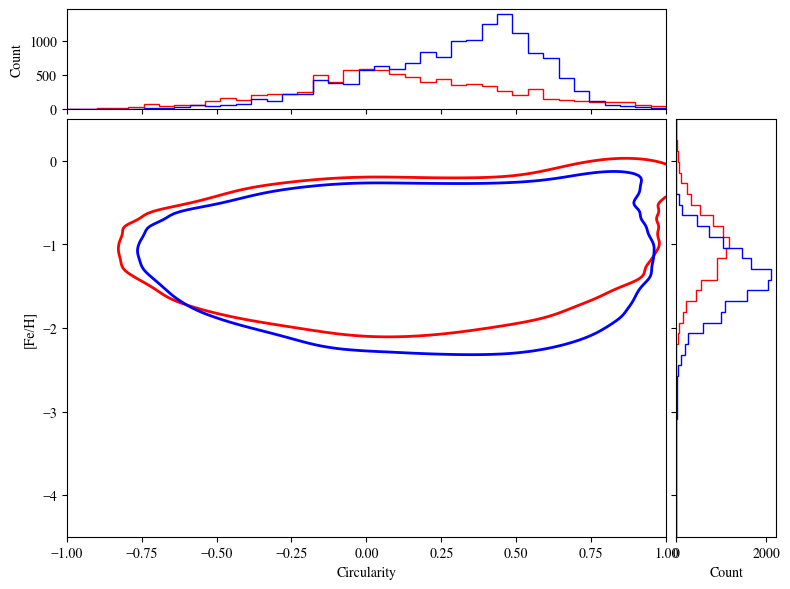

In [16]:
cont_level = 0.95
hist_density = False

# -----------------------
# Figure + axes
# -----------------------
fig, ax_scatter = plt.subplots(figsize=(8, 6))

divider = make_axes_locatable(ax_scatter)
ax_histx = divider.append_axes("top", 1.0, pad=0.1, sharex=ax_scatter)
ax_histy = divider.append_axes("right", 1.0, pad=0.1, sharey=ax_scatter)

ax_histx.tick_params(labelbottom=False)
ax_histy.tick_params(labelleft=False)

# -----------------------
# KDE grid
# -----------------------
x_grid = np.linspace(-1.0, 1.0, 200)
y_grid = np.linspace(-4.5, 0.5, 200)

XX, YY = np.meshgrid(x_grid, y_grid)
grid_positions = np.vstack([XX.ravel(), YY.ravel()])

Z_total = np.zeros_like(XX)
n_iter = 0

# -----------------------
# storage for histograms
# -----------------------
hist_dict = {
    "ins": {"x": np.array([]), "y": np.array([])},
    "exs": {"x": np.array([]), "y": np.array([])},
}

colors = {"ins": "r", "exs": "b"}

# -----------------------
# MAIN LOOP
# -----------------------
for k in ["ins", "exs"]:  # keep simple like your example
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        in_flag = src_dat["grpid"][()] == 0
        s_flag = src_dat["s_flag"][()].astype(bool)

        # --- compute circularity (same as your code) ---
        pxyz = src_dat["pxyz_snap600"][()]
        vxyz = src_dat["vxyz_snap600"][()]

        posvel = np.column_stack((pxyz, vxyz))
        lz = af(posvel)[:, 2]

        ek = 0.5 * np.sum(vxyz**2, axis=1)
        ep = pot_nbody.potential(pxyz)
        et = ek + ep

        r_circs = pot_nbody.Rcirc(E=et)
        xyz = np.column_stack((r_circs, 0 * r_circs, 0 * r_circs))
        v_circs = np.sqrt(-r_circs * pot_nbody.force(xyz)[:, 0])
        vel = np.column_stack((0 * v_circs, v_circs, 0 * v_circs))

        init_conds = np.concatenate((xyz, vel), axis=1)
        lz_circ = af(init_conds)[:, 2]

        circularity = lz / lz_circ

        feh = src_dat["feh"][()]

        # --- masks ---
        if k == "ins":
            mask = in_flag & s_flag
        elif k == "exs":
            mask = ~in_flag & s_flag

        x_i = circularity[mask]
        y_i = feh[mask]

        # store for marginal hist
        hist_dict[k]["x"] = np.concatenate((hist_dict[k]["x"], x_i))
        hist_dict[k]["y"] = np.concatenate((hist_dict[k]["y"], y_i))

        if len(x_i) < 20:
            continue

        data = np.vstack([x_i, y_i])
        kde = gaussian_kde(data)
        Z = kde(grid_positions).reshape(XX.shape)

        Z_total += Z
        n_iter += 1

    # -----------------------
    # average KDE
    # -----------------------
    Z_avg = Z_total / n_iter

    # -----------------------
    # contour level (same method as yours)
    # -----------------------
    Z_flat = Z_avg.ravel()
    idx = np.argsort(Z_flat)[::-1]
    Z_sorted = Z_flat[idx]

    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]

    level = Z_sorted[np.searchsorted(cumsum, cont_level)]

    ax_scatter.contour(XX, YY, Z_avg, levels=[level], colors=colors[k], linewidths=2)

# -----------------------
# Marginal histograms
# -----------------------
bins_x = np.linspace(-1, 1, 40)
bins_y = np.linspace(-4.5, 0.5, 40)

for k in ["ins", "exs"]:
    ax_histx.hist(hist_dict[k]["x"], bins=bins_x, histtype="step", color=colors[k], density=hist_density)

    ax_histy.hist(
        hist_dict[k]["y"],
        bins=bins_y,
        orientation="horizontal",
        histtype="step",
        color=colors[k],
        density=hist_density,
    )

# -----------------------
# Labels + limits
# -----------------------
ax_scatter.set_xlim(-1, 1)
ax_scatter.set_ylim(-4.5, 0.5)

ax_scatter.set_xlabel("Circularity")
ax_scatter.set_ylabel("[Fe/H]")

ax_histx.set_ylabel("Density" if hist_density else "Count")
ax_histy.set_xlabel("Density" if hist_density else "Count")

plt.tight_layout()
plt.show()

In [17]:
min_logmass = np.arange(4, 6.1, 0.1)

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim = "m12b"
mass_loss_dict = {sim: {"avg": [], "std": []} for sim in sim_lst}


for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    for min_mass in min_logmass:
        mass_diff_i = []
        for it_id in ghost_data.keys():
            # it_id = "it001"

            src_dat = ghost_data[it_id]["source"]
            logm_tfor = src_dat["logm_tfor"][()]
            m_tfo = 10.0**logm_tfor
            m_tfo_ev = 0.55 * m_tfo  # stellar-evolution corrected mass

            logm_tz0 = src_dat["logm_tz0"][()]

            m_tz0 = 10**logm_tz0
            m_tz0[logm_tz0 == -1] = 0

            m_msk = min_mass < logm_tfor

            m_diff = np.sum(m_tfo_ev[m_msk] - m_tz0[m_msk])
            mass_diff_i.append(m_diff)

        mass_loss_dict[sim]["avg"].append(np.mean(mass_diff_i))
        mass_loss_dict[sim]["std"].append(np.std(mass_diff_i))


Text(0, 0.5, 'Stellar Mass Originating in GCs [M$_{\\odot}$]')

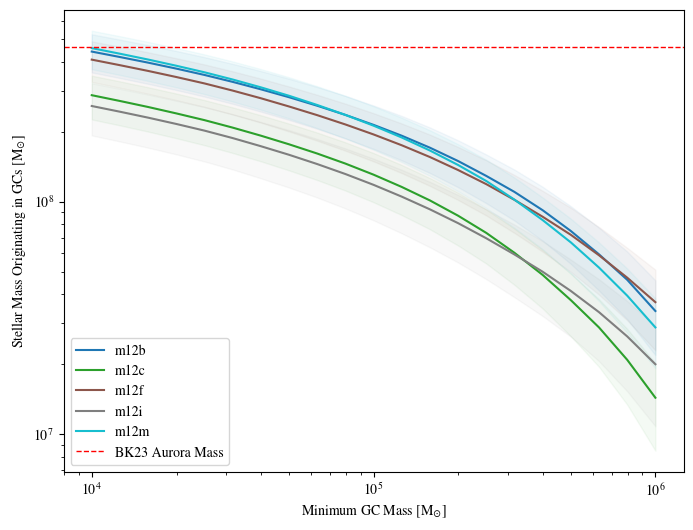

In [20]:
plt_error = True

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

for sim in sim_lst:
    ax.plot(10**min_logmass, mass_loss_dict[sim]["avg"], label=sim, c=sim_colors[sim])

    if plt_error:
        ax.fill_between(
            10**min_logmass,
            np.array(mass_loss_dict[sim]["avg"]) - np.array(mass_loss_dict[sim]["std"]),
            np.array(mass_loss_dict[sim]["avg"]) + np.array(mass_loss_dict[sim]["std"]),
            color=sim_colors[sim],
            alpha=0.05,
        )

ax.axhline(4.6 * 10**8, label="BK23 Aurora Mass", c="r", ls="--", lw=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.legend(loc="lower left")
ax.set_xlabel(r"Minimum GC Mass [M$_{\odot}$]")
ax.set_ylabel(r"Stellar Mass Originating in GCs [M$_{\odot}$]")